# Kaggle Competition on Prediction of Health Risk: A Project by Upamanyu Moitra, PhD

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data Exploration

In [2]:
df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [4]:
num_cols = ['sleep_duration', 'heart_rate', 'bmi', \
            'calorie_expenditure', 'step_count', \
           'exercise_duration', 'water_intake']
cat_cols = ['diet_type', 'stress_level', 'sleep_quality', \
            'physical_activity_level', 'smoking_alcohol', \
           'gender']

In [5]:
for col in cat_cols:
    print("*"*50)
    print(f"Unique categories for column {col}")
    print(df[col].unique())

**************************************************
Unique categories for column diet_type
['veg' 'non-veg' 'balanced' nan]
**************************************************
Unique categories for column stress_level
['high' 'low' nan 'medium']
**************************************************
Unique categories for column sleep_quality
['average' 'poor' nan 'good']
**************************************************
Unique categories for column physical_activity_level
['sedentary' 'moderate' 'active' nan]
**************************************************
Unique categories for column smoking_alcohol
['yes' 'occasional' nan 'no']
**************************************************
Unique categories for column gender
['female' 'other' 'male' nan]


In [6]:
df.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [7]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       295753 non-null  int64  
 1   sleep_duration           263182 non-null  float64
 2   heart_rate               292396 non-null  float64
 3   bmi                      289797 non-null  float64
 4   calorie_expenditure      273101 non-null  float64
 5   step_count               289789 non-null  float64
 6   exercise_duration        292795 non-null  float64
 7   water_intake             277120 non-null  float64
 8   diet_type                292795 non-null  object 
 9   stress_level             260263 non-null  object 
 10  sleep_quality            270754 non-null  object 
 11  physical_activity_level  280058 non-null  object 
 12  smoking_alcohol          283504 non-null  object 
 13  gender                   286593 non-null  object 
dtypes: f

In [9]:
df_test.isna().sum()

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

In [10]:
df['health_condition'].unique()

array(['unhealthy', 'at-risk', 'fit'], dtype=object)

In [11]:
df['health_condition'].value_counts(normalize = True)

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64

In [12]:
df.groupby(df["stress_level"].isna())["health_condition"].value_counts(normalize=True)

stress_level  health_condition
False         at-risk             0.858638
              unhealthy           0.083655
              fit                 0.057707
True          at-risk             0.858944
              unhealthy           0.083588
              fit                 0.057468
Name: proportion, dtype: float64

In [13]:
for col in num_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df_test[f"{col}_missing"] = df_test[col].isna().astype(int)

In [14]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,...,physical_activity_level,smoking_alcohol,gender,sleep_duration_missing,heart_rate_missing,bmi_missing,calorie_expenditure_missing,step_count_missing,exercise_duration_missing,water_intake_missing
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,...,sedentary,yes,female,0,0,0,0,0,0,0
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,...,moderate,yes,other,0,0,0,0,0,0,0
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,...,active,yes,male,0,0,0,0,0,0,0
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,...,active,occasional,female,0,0,0,0,0,0,0
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,...,sedentary,NaN,male,0,0,0,0,0,0,0


### Data Visualization

#### Histograms of the Numerical Features (Are mon-linear transformation necessary? No)

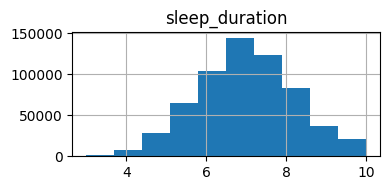

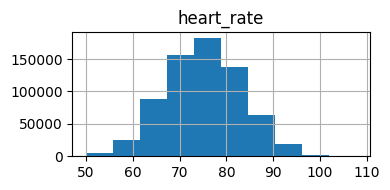

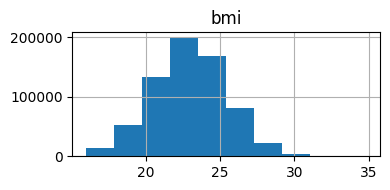

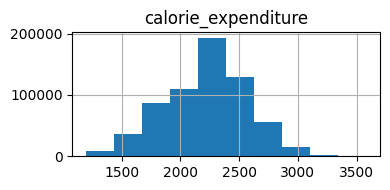

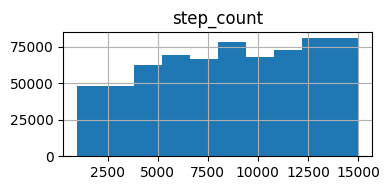

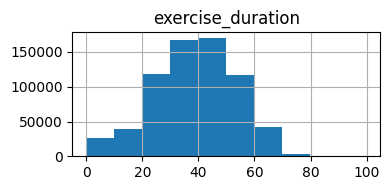

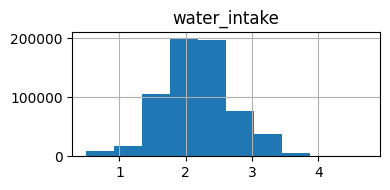

In [15]:
for col in num_cols:
    plt.figure(figsize = (4,2))
    df[col].hist()
    plt.title(col)
    plt.tight_layout()
    plt.show()

### Target and Features

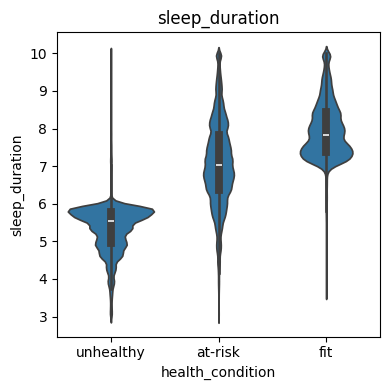

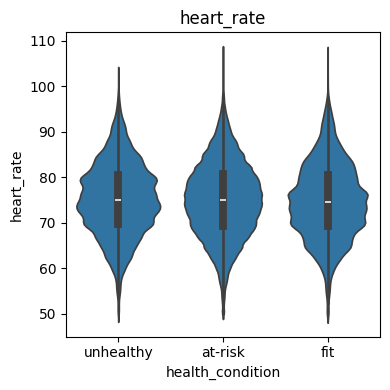

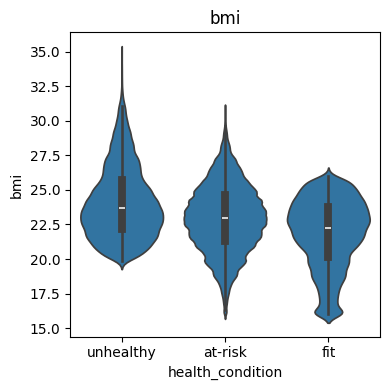

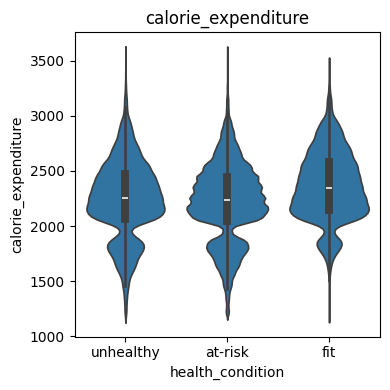

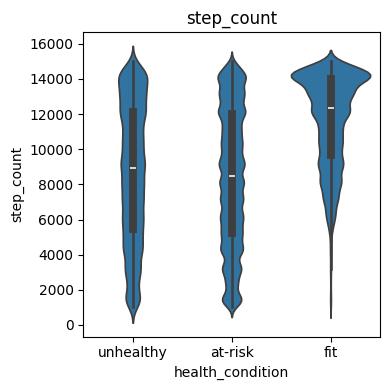

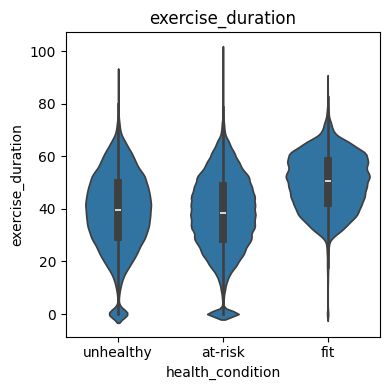

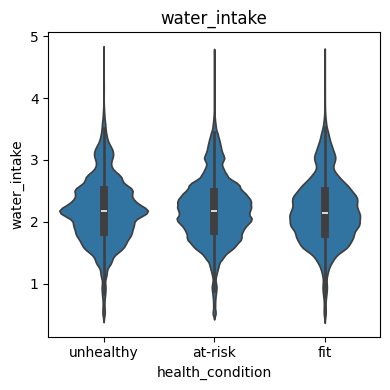

In [16]:
for col in num_cols:
    plt.figure(figsize=(4, 4))
    sns.violinplot(data=df, x="health_condition", y=col)
    plt.title(col)
    plt.tight_layout()
    plt.show()

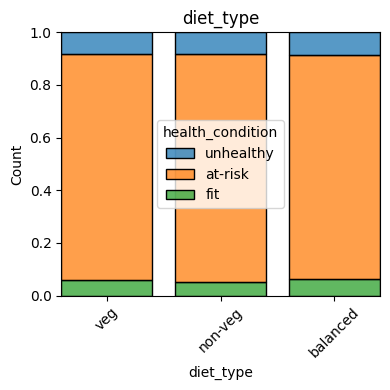

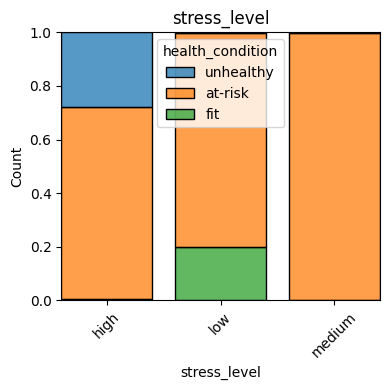

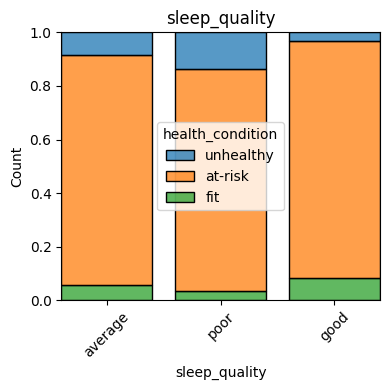

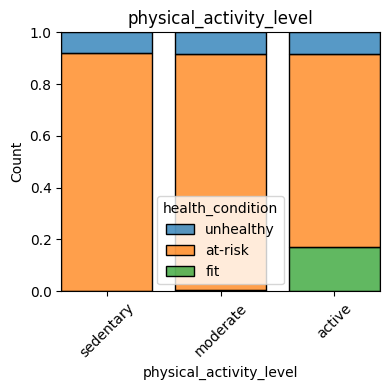

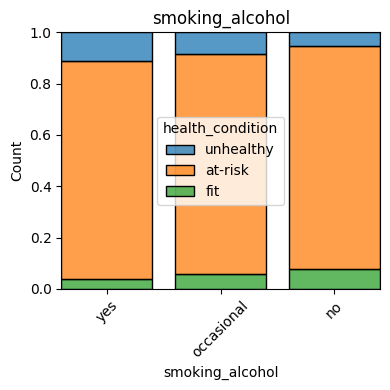

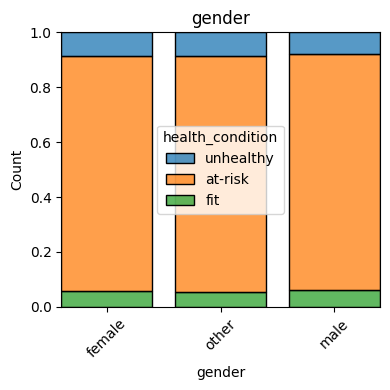

In [17]:
for col in cat_cols:
    plt.figure(figsize=(4,4))
    sns.histplot(data=df, x=col, hue="health_condition",\
                 multiple="fill", shrink=.8)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.tight_layout()
    plt.show()

# Data Engineering 

## Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [19]:
class_encoding = LabelEncoder()

In [20]:
X, y = df.drop(columns = ['id','health_condition']), df['health_condition'].values

In [21]:
y = class_encoding.fit_transform(y)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y,\
                                                   stratify = y,
                                                   test_size = 0.2,\
                                                   random_state = 137)

## Data Imputation

In [23]:
for col in num_cols:
    train_median = X_train[col].median()
    print(f"For columns {col} the median is {train_median}")
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col]  = X_test[col].fillna(train_median)
    df_test[col] = df_test[col].fillna(train_median)

For columns sleep_duration the median is 6.99
For columns heart_rate the median is 75.1
For columns bmi the median is 23.0
For columns calorie_expenditure the median is 2240.0
For columns step_count the median is 8856.0
For columns exercise_duration the median is 39.4
For columns water_intake the median is 2.17


In [24]:
for col in cat_cols:
    X_train[col] = X_train[col].fillna('Missing')
    X_test[col] = X_test[col].fillna('Missing')
    df_test[col] = df_test[col].fillna('Missing')

In [25]:
X_train.isna().sum()

sleep_duration                 0
heart_rate                     0
bmi                            0
calorie_expenditure            0
step_count                     0
exercise_duration              0
water_intake                   0
diet_type                      0
stress_level                   0
sleep_quality                  0
physical_activity_level        0
smoking_alcohol                0
gender                         0
sleep_duration_missing         0
heart_rate_missing             0
bmi_missing                    0
calorie_expenditure_missing    0
step_count_missing             0
exercise_duration_missing      0
water_intake_missing           0
dtype: int64

In [26]:
df_test.isna().sum()

id                             0
sleep_duration                 0
heart_rate                     0
bmi                            0
calorie_expenditure            0
step_count                     0
exercise_duration              0
water_intake                   0
diet_type                      0
stress_level                   0
sleep_quality                  0
physical_activity_level        0
smoking_alcohol                0
gender                         0
sleep_duration_missing         0
heart_rate_missing             0
bmi_missing                    0
calorie_expenditure_missing    0
step_count_missing             0
exercise_duration_missing      0
water_intake_missing           0
dtype: int64

## Feature Engineering

In [27]:
for col in num_cols:
    print(col, X_train[col].min(), X_train[col].max())

sleep_duration 3.0 10.0
heart_rate 50.0 107.7
bmi 16.0 34.82
calorie_expenditure 1200.0 3580.0
step_count 1002.0 14999.0
exercise_duration 0.0 99.8
water_intake 0.5 4.72


#### Calories per Step

In [28]:
X_train['calories_per_step'] = X_train['calorie_expenditure']/X_train['step_count']
X_test['calories_per_step'] = X_test['calorie_expenditure']/X_test['step_count']
df_test['calories_per_step'] = df_test['calorie_expenditure']/df_test['step_count']
#For visualization
df['calories_per_step'] = df['calorie_expenditure']/df['step_count']

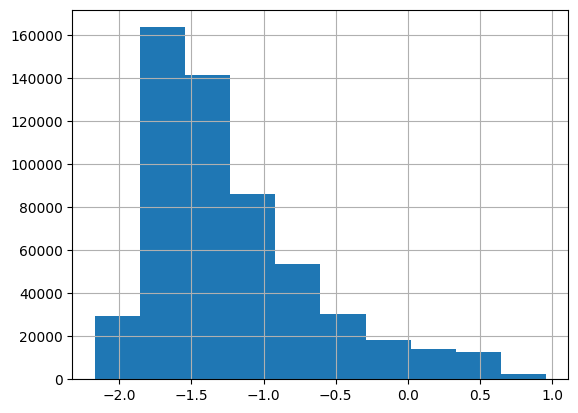

In [29]:
np.log(X_train['calories_per_step']).hist()
plt.show()
#The log plot looks better

In [30]:
X_train['calories_per_step'] = np.log(X_train['calories_per_step'])
X_test['calories_per_step']  = np.log(X_test['calories_per_step'])
df_test['calories_per_step'] = np.log(df_test['calories_per_step'])
#For visualization
df['calories_per_step'] = np.log(df['calories_per_step'])

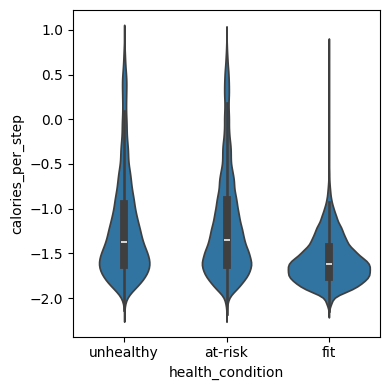

In [31]:
plt.figure(figsize = (4,4))
sns.violinplot(data=df, x="health_condition", y='calories_per_step')
plt.tight_layout()
plt.show()

#### Water Intake per BMI

In [32]:
X_train['water_per_BMI'] = X_train['water_intake']/X_train['bmi']
X_test['water_per_BMI'] = X_test['water_intake']/X_test['bmi']
df_test['water_per_BMI'] = df_test['water_intake']/df_test['bmi']
#For visulization
df['water_per_BMI'] = df['water_intake']/df['bmi']

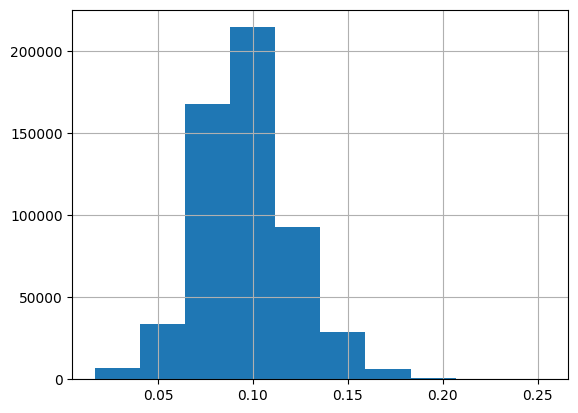

In [33]:
X_train['water_per_BMI'].hist()
plt.show()

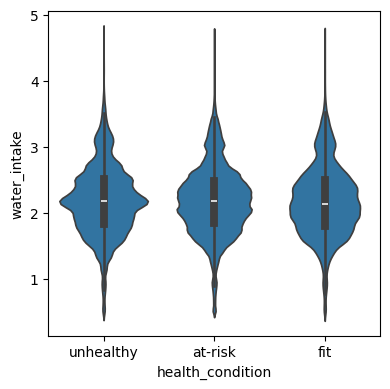

In [34]:
plt.figure(figsize = (4,4))
sns.violinplot(data=df, x="health_condition", y='water_intake')
plt.tight_layout()
plt.show()

#### Exercise Duration Per Calories Spent

In [35]:
X_train['exercise_per_calorie'] = X_train['exercise_duration']/ \
                                  X_train['calorie_expenditure']
X_test['exercise_per_calorie'] = X_test['exercise_duration'] / \
                                 X_test['calorie_expenditure']
df_test['exercise_per_calorie'] = df_test['exercise_duration'] / \
                                df_test['calorie_expenditure']
#For visualization
df['exercise_per_calorie'] = df['exercise_duration'] / \
                                df['calorie_expenditure']

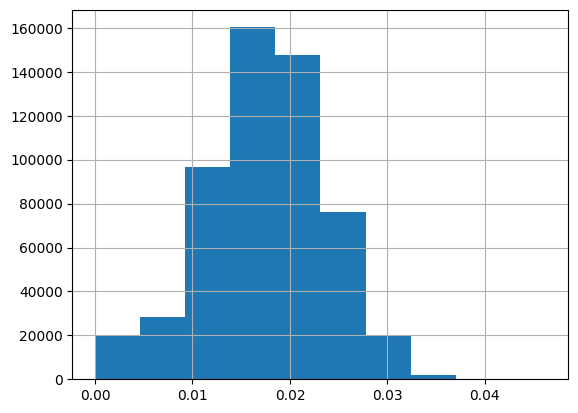

In [36]:
X_train['exercise_per_calorie'].hist()
plt.show()

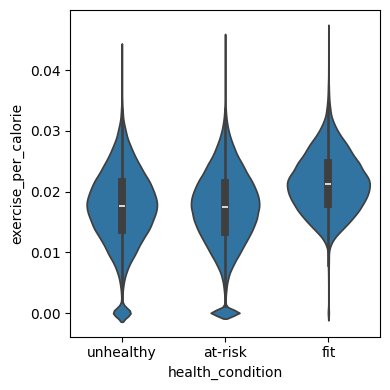

In [37]:
plt.figure(figsize = (4,4))
sns.violinplot(data=df, x="health_condition", y='exercise_per_calorie')
plt.tight_layout()
plt.show()

#### Heart Rate Time Exercise Duration

In [38]:
X_train['heart_times_exer'] = X_train['heart_rate']* \
                              X_train['exercise_duration']
X_test['heart_times_exer'] = X_test['heart_rate']* \
                              X_test['exercise_duration']
df_test['heart_times_exer'] = df_test['heart_rate']* \
                              df_test['exercise_duration']
#Visualization
df['heart_times_exer'] = df['heart_rate']* \
                              df['exercise_duration']

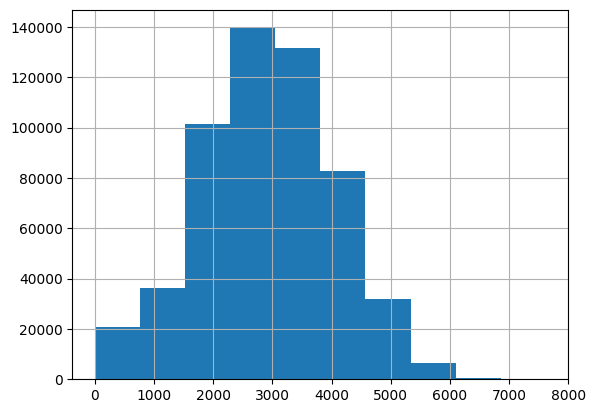

In [39]:
X_train['heart_times_exer'].hist()
plt.show()

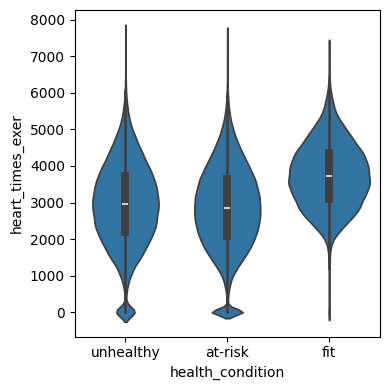

In [40]:
plt.figure(figsize = (4,4))
sns.violinplot(data=df, x="health_condition", y='heart_times_exer')
plt.tight_layout()
plt.show()

#### Dimensionless Ratio: Exercise Duration / Sleep Duration

In [41]:
X_train['exer_per_sleep'] = X_train['exercise_duration'] / \
                       X_train['sleep_duration']
X_test['exer_per_sleep'] = X_test['exercise_duration'] / \
                           X_test['sleep_duration']
df_test['exer_per_sleep'] = df_test['exercise_duration'] / \
                            df_test['sleep_duration']
#Visualization
df['exer_per_sleep'] = df['exercise_duration'] / \
                            df['sleep_duration']

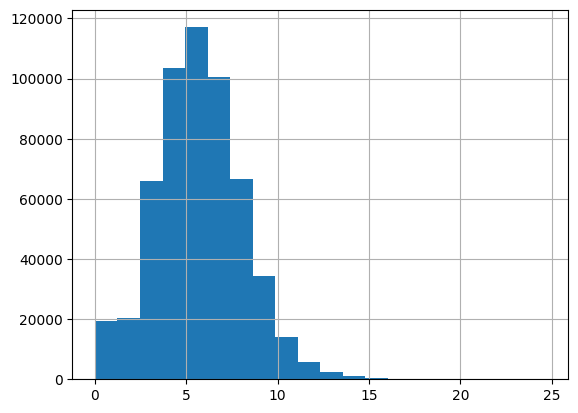

In [42]:
X_train['exer_per_sleep'].hist(bins = 20)
plt.show()

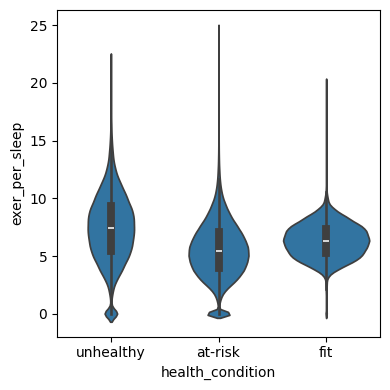

In [43]:
plt.figure(figsize = (4,4))
sns.violinplot(data=df, x="health_condition", y='exer_per_sleep')
plt.tight_layout()
plt.show()

In [44]:
X_train.columns

Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender', 'sleep_duration_missing',
       'heart_rate_missing', 'bmi_missing', 'calorie_expenditure_missing',
       'step_count_missing', 'exercise_duration_missing',
       'water_intake_missing', 'calories_per_step', 'water_per_BMI',
       'exercise_per_calorie', 'heart_times_exer', 'exer_per_sleep'],
      dtype='object')

In [45]:
X_train.head()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,...,bmi_missing,calorie_expenditure_missing,step_count_missing,exercise_duration_missing,water_intake_missing,calories_per_step,water_per_BMI,exercise_per_calorie,heart_times_exer,exer_per_sleep
370019,7.53,77.6,20.85,2535.0,11139.0,22.8,1.92,veg,low,good,...,0,0,0,0,0,-1.480259,0.092086,0.008994,1769.28,3.027888
506115,7.87,74.5,22.53,2248.0,13272.0,40.6,2.23,veg,medium,average,...,0,0,0,0,0,-1.775616,0.098979,0.018060,3024.70,5.158831
280485,6.68,71.5,17.77,2122.0,13258.0,48.9,1.71,non-veg,Missing,average,...,0,0,0,0,0,-1.832242,0.096230,0.023044,3496.35,7.320359
299821,7.50,75.1,16.00,2055.0,14266.0,74.8,2.30,veg,low,average,...,0,0,0,0,0,-1.937603,0.143750,0.036399,5617.48,9.973333
135242,8.31,78.1,24.62,2128.0,12129.0,42.7,2.59,balanced,medium,good,...,0,0,0,0,0,-1.740417,0.105199,0.020066,3334.87,5.138387


In [46]:
#Keeping a copy for later, if needed
X_train_b, X_test_b, y_train_b, y_test_b = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

## Data Encoding

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [48]:
col_transf = ColumnTransformer(
    transformers = [ ("ohe", OneHotEncoder(), cat_cols)],
    remainder = 'passthrough',
)

In [49]:
X_train = col_transf.fit_transform(X_train)

In [50]:
X_test = col_transf.transform(X_test)

In [51]:
X_test_final = df_test.drop(columns = 'id')

In [52]:
X_test_final = col_transf.transform(X_test_final)

In [53]:
print(X_test.shape, X_test_final.shape)

(138018, 43) (295753, 43)


In [54]:
X_train[0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        7.53000000e+00,  7.76000000e+01,  2.08500000e+01,  2.53500000e+03,
        1.11390000e+04,  2.28000000e+01,  1.92000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.48025883e+00,  9.20863309e-02,
        8.99408284e-03,  1.76928000e+03,  3.02788845e+00])

### Scaling

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scal = StandardScaler()

In [57]:
X_train = scal.fit_transform(X_train)
X_test  = scal.transform(X_test)
X_test_final = scal.transform(X_test_final)

# Fitting Models

In [58]:
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
pipe_lr = LogisticRegression(max_iter = 10000, random_state = 137,\
                             class_weight = 'balanced', solver = 'lbfgs')
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

In [61]:
grid_search_lr = GridSearchCV(estimator = pipe_lr, 
                           param_grid = param_grid_lr, 
                           cv=5, 
                           scoring='balanced_accuracy', 
                           n_jobs=-1
                          )

In [62]:
%%time
grid_search_lr.fit(X_train, y_train)

CPU times: user 55.7 s, sys: 375 ms, total: 56.1 s
Wall time: 1min 53s


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=10000, random_state=137),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100]},
             scoring='balanced_accuracy')

In [63]:
best_model_lr = grid_search_lr.best_estimator_
print('Best Parameters:', grid_search_lr.best_params_)
y_pred_lr = best_model_lr.predict(X_test)

Best Parameters: {'C': 10}


In [64]:
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)
print(f"Balanced accuracy score is {bal_acc_lr:.4f}")

Balanced accuracy score is 0.9195


In [65]:
best_model_lr.fit(X_train, y_train)
y_pred_lr = best_model_lr.predict(X_test)

In [66]:
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)
print(f"Balanced accuracy score is {bal_acc_lr:.4f}")

Balanced accuracy score is 0.9195


## Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
pipe_rfc = RandomForestClassifier(random_state=137,
                                  class_weight = 'balanced')
param_grid_rfc = {'n_estimators': [10, 50, 100],\
                  'max_depth': [None, 5, 10],\
                  'min_samples_split': [2, 5]}

In [69]:
random_search_rfc = RandomizedSearchCV(
    estimator = pipe_rfc,
    param_distributions = param_grid_rfc,
    n_iter = 8,
    cv = 5,
    scoring = 'balanced_accuracy',
    random_state = 137,
    n_jobs = -1)

In [70]:
%%time
random_search_rfc.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CPU times: user 2min 52s, sys: 1.38 s, total: 2min 54s
Wall time: 26min 41s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=137),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [10, 50, 100]},
                   random_state=137, scoring='balanced_accuracy')

In [71]:
best_model_rfc = random_search_rfc.best_estimator_
y_pred_rfc = best_model_rfc.predict(X_test)

In [72]:
bal_acc_rfc = balanced_accuracy_score(y_test, y_pred_rfc)
print(f"Balanced accuracy score is {bal_acc_rfc:.4f}")

Balanced accuracy score is 0.9477


This was way too time-consuming, as one would expect. 

## LightGBM

In [73]:
from lightgbm import LGBMClassifier

In [74]:
pipe_lgbm = LGBMClassifier(random_state=137,\
                           objective = 'multiclass',\
                           class_weight = 'balanced',\
                           verbose = -1
                          )
param_grid_lgbm = {'num_leaves': [31, 50, 63],\
                   'max_depth': [-1, 5, 10],\
                   'learning_rate': [0.01, 0.1, 0.2],\
                   'n_estimators': [50, 100, 200]}

In [75]:
random_search_lgbm = RandomizedSearchCV(
    estimator = pipe_lgbm,
    param_distributions = param_grid_lgbm,
    n_iter = 8,
    cv = 5,
    scoring = 'balanced_accuracy',
    random_state = 137,
    n_jobs = -1)

In [76]:
%%time
random_search_lgbm.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warning

CPU times: user 25.3 s, sys: 847 ms, total: 26.1 s
Wall time: 10min 12s


RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            objective='multiclass',
                                            random_state=137, verbose=-1),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [-1, 5, 10],
                                        'n_estimators': [50, 100, 200],
                                        'num_leaves': [31, 50, 63]},
                   random_state=137, scoring='balanced_accuracy')

In [77]:
best_model_lgbm = random_search_lgbm.best_estimator_
y_pred_lgbm = best_model_lgbm.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [78]:
bal_acc_lgbm = balanced_accuracy_score(y_test, y_pred_lgbm)
print(f"Balanced accuracy score is {bal_acc_lgbm:.4f}")

Balanced accuracy score is 0.9500


## XGBoost Classifier

In [79]:
from xgboost import XGBClassifier

In [80]:
pipe_xgb = XGBClassifier(objective='multi:softprob',\
                         num_class=3,\
                         eval_metric='mlogloss',\
                         random_state=137
                        )
param_grid_xgb = {
    'n_estimators': [50, 100, 200],\
    'max_depth': [3, 5, 7],\
    'learning_rate': [0.01, 0.1, 0.2]
}

In [81]:
random_search_xgb = RandomizedSearchCV(
    estimator = pipe_xgb,
    param_distributions = param_grid_xgb,
    n_iter = 8,
    cv = 5,
    scoring = 'balanced_accuracy',
    random_state = 137,
    n_jobs = -1)

In [84]:
%%time
random_search_xgb.fit(X_train, y_train)

CPU times: user 1min 8s, sys: 692 ms, total: 1min 8s
Wall time: 7min 30s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_class=3, ...),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [50, 100, 200]},
                   random_state=137, scoring='balanced_accuracy')

In [85]:
best_model_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)

In [86]:
bal_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)
print(f"Balanced accuracy score is {bal_acc_xgb:.4f}")

Balanced accuracy score is 0.8770


## CatBoost

In [87]:
from catboost import CatBoostClassifier

In [88]:
pipe_cat = CatBoostClassifier(random_seed = 137,
                              verbose = 0,
                              classes_count = 3)
param_grid_cat = {'iterations': [50, 100, 150],\
                  'learning_rate': [0.01, 0.05, 0.1, 0.2],\
                  'depth': [3, 4, 5, 6],\
                  'l2_leaf_reg': [1, 3, 5, 7]}

In [89]:
random_search_cat = RandomizedSearchCV(
    estimator = pipe_cat,
    param_distributions = param_grid_cat,
    n_iter = 8,
    cv = 5,
    scoring = 'balanced_accuracy',
    random_state = 137,
    n_jobs = -1)

In [92]:
%%time
random_search_cat.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CPU times: user 1min 37s, sys: 4.18 s, total: 1min 41s
Wall time: 9min 43s


RandomizedSearchCV(cv=5,
                   estimator=CatBoostClassifier(classes_count=3, random_seed=137, verbose=0),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'depth': [3, 4, 5, 6],
                                        'iterations': [50, 100, 150],
                                        'l2_leaf_reg': [1, 3, 5, 7],
                                        'learning_rate': [0.01, 0.05, 0.1,
                                                          0.2]},
                   random_state=137, scoring='balanced_accuracy')

In [93]:
best_model_cat = random_search_cat.best_estimator_
y_pred_cat = best_model_cat.predict(X_test)

In [94]:
bal_acc_cat = balanced_accuracy_score(y_test, y_pred_cat)
print(f"Balanced accuracy score is {bal_acc_cat:.4f}")

Balanced accuracy score is 0.8676


## Deep Learning

In [95]:
import tensorflow as tf

In [96]:
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras import regularizers

In [97]:
from sklearn.utils.class_weight import compute_class_weight

In [98]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight = "balanced",\
                               classes = classes,\
                               y = y_train)

In [99]:
class_weights = dict(zip(classes, weights))

In [100]:
def build_model(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape = (input_dim, )),
        layers.BatchNormalization(),
        
        layers.Dense(256,\
                    activation = 'gelu',\
                    kernel_regularizer = regularizers.l2(1e-4)),
        layers.Dropout(0.30),
        layers.BatchNormalization(),

        layers.Dense(128,\
                    activation = 'gelu',\
                    kernel_regularizer = regularizers.l2(1e-4)),
        layers.Dropout(0.25),
        layers.BatchNormalization(),

        layers.Dense(64,
                    activation = 'gelu'),

        layers.Dense(3,
                    activation = 'softmax')

            
    ])
    return model

In [101]:
optimizer = tf.keras.optimizers.AdamW(learning_rate = 5e-4)

model = build_model(X_train.shape[1])

model.compile(optimizer = optimizer,
              loss = "sparse_categorical_crossentropy",
              metrics = ['accuracy']
             )

2026-07-31 13:03:13.698508: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [102]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 43)             │           172 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,319 (212.18 KB)

 Trainable params: 53,465 (208.85 KB)

 Non-trainable params: 854 (3.34 KB)

In [103]:
class BalancedAccuracy(callbacks.Callback):
    def __init__(self, X_test, y_test):
        self.X_test = X_test
        self.y_test = y_test

    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(
            self.X_test,
            verbose=0
        )
        pred = np.argmax(pred, axis=1)
        score = balanced_accuracy_score(
            self.y_test,
            pred
        )
        print(f"\nBalanced Accuracy = {score:.4f}")

In [104]:
early_stop = callbacks.EarlyStopping(monitor="val_loss",\
                                     patience=20,\
                                     restore_best_weights=True
                                    )

In [105]:
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.3,
                                        patience=8,
                                        verbose=1)

In [106]:
checkpoint = callbacks.ModelCheckpoint("best_model.keras",\
                                       save_best_only=True
                                      )

In [107]:
balanced_callback = BalancedAccuracy(X_test, y_test)

In [108]:
history = model.fit(X_train, y_train,\
                    validation_data = (X_test, y_test),\
                    epochs = 200,\
                    batch_size = 1024,\
                    class_weight = class_weights,\
                    callbacks = [early_stop,\
                                reduce_lr,\
                                checkpoint,\
                                balanced_callback],\
                    verbose = 1
                   )

Epoch 1/200
539/540 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7377 - loss: 0.5097
Balanced Accuracy = 0.9376
540/540 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8329 - loss: 0.3551 - val_accuracy: 0.9076 - val_loss: 0.2723 - learning_rate: 5.0000e-04
Epoch 2/200
537/540 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9068 - loss: 0.2550
Balanced Accuracy = 0.9425
540/540 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.9109 - loss: 0.2483 - val_accuracy: 0.9193 - val_loss: 0.2503 - learning_rate: 5.0000e-04
Epoch 3/200
537/540 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9181 - loss: 0.2335
Balanced Accuracy = 0.9443
540/540 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9199 - loss: 0.2299 - val_accuracy: 0.9251 - val_loss: 0.2232 - learning_rate: 5.0000e-04
Epoch 4/200
539/540 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9227 - loss: 0.2227
Balanced Accuracy = 0.9453
540/540 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9232 - loss: 0.2217 - val_accuracy: 0.9253

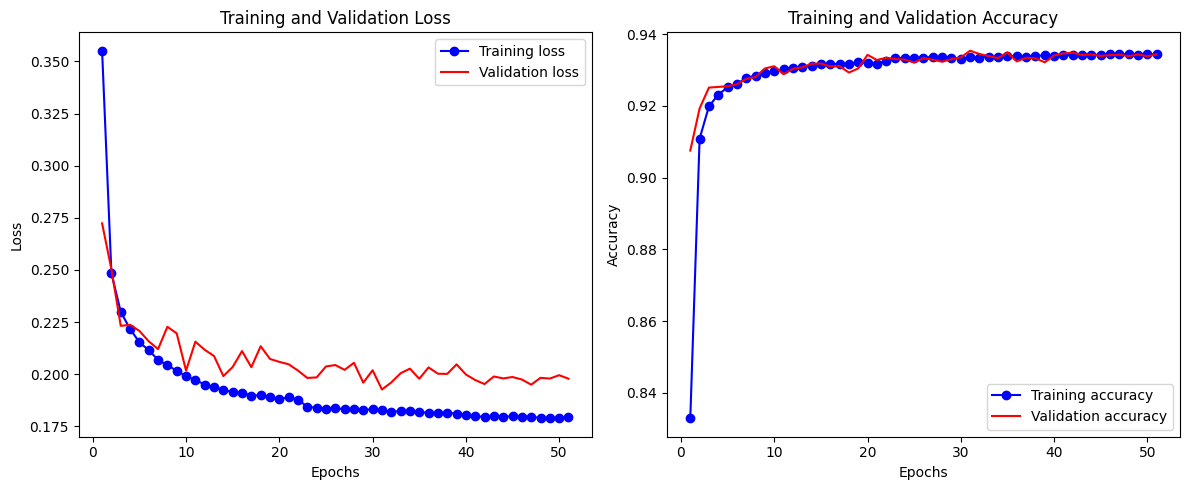

In [109]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'r-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'bo-', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [110]:
prob_dl = model.predict(X_test)
y_pred_dl = np.argmax(prob_dl, axis=1)
bal_acc_dl = balanced_accuracy_score(y_test, y_pred_dl)
print(f"Balanced accuracy score is {bal_acc_dl:.4f}")

4314/4314 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Balanced accuracy score is 0.9491


In [111]:
best_epoch = np.argmin(history.history['val_loss']) + 1
print(best_epoch)

31


# Final Results

## An Ensemble Classifier

In [112]:
weights = [1, 4, 2]

In [113]:
ensemble_probs =  (weights[0]*best_model_rfc.predict_proba(X_test) + 
weights[1]*best_model_lgbm.predict_proba(X_test) + 
weights[2]*model.predict(X_test))/sum(weights)

pred = ensemble_probs.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


4314/4314 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


In [114]:
balanced_accuracy_score(y_test, pred)

np.float64(0.9501419705986045)

## Retraining with Full Data

In [115]:
X_full = np.concatenate([X_train, X_test], axis=0)
y_full = np.concatenate([y_train, y_test], axis=0)
print(X_full.shape, y_full.shape)

(690088, 43) (690088,)


In [116]:
%%time
best_model_rfc.fit(X_full, y_full)

CPU times: user 3min 22s, sys: 37.5 ms, total: 3min 22s
Wall time: 3min 23s


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=137)

In [117]:
%%time
best_model_lgbm.fit(X_full, y_full)

CPU times: user 26.1 s, sys: 0 ns, total: 26.1 s
Wall time: 13.3 s


LGBMClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
               num_leaves=50, objective='multiclass', random_state=137,
               verbose=-1)

In [118]:
optimizer = tf.keras.optimizers.AdamW(learning_rate = 5e-4)
model = build_model(X_full.shape[1])

In [119]:
model.compile(optimizer = optimizer,
              loss = "sparse_categorical_crossentropy",
              metrics = ['accuracy']
             )

In [120]:
history = model.fit(X_full, y_full,\
                    epochs= best_epoch,\
                    batch_size=1024,
                    class_weight=class_weights,
                    verbose=1)

Epoch 1/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8466 - loss: 0.3257
Epoch 2/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9160 - loss: 0.2368
Epoch 3/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9227 - loss: 0.2222
Epoch 4/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9250 - loss: 0.2150
Epoch 5/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9267 - loss: 0.2095
Epoch 6/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9282 - loss: 0.2050
Epoch 7/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9291 - loss: 0.2010
Epoch 8/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9301 - loss: 0.1981
Epoch 9/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9305 - loss: 0.1960
Epoch 10/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9313 - loss: 0.1945
Epoch 11/31
674/674 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9313 - loss: 0.1926
Epoch 12/31
674/674 ━━━━━━━━━━

## Final Data Preparation

In [121]:
ensemble_probs_final =  (weights[0]*best_model_rfc.predict_proba(X_test_final) + 
weights[1]*best_model_lgbm.predict_proba(X_test_final) + 
weights[2]*model.predict(X_test_final))/sum(weights)

y_pred_final = ensemble_probs_final.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


9243/9243 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


In [122]:
y_pred_final

array([2, 2, 0, ..., 2, 0, 2])

In [123]:
y_final = class_encoding.inverse_transform(y_pred_final)

In [124]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'health_condition': y_final
})

In [125]:
submission

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk


In [126]:
submission.to_csv('submission.csv', index=False)